# Set up

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

# Data

In [29]:
from pyFAI.gui import jupyter

In [35]:
path = r"\\Synology\Data\2025\SC5671-ID13\RAW_DATA\COPO-500-STR75C-2\sc5671_COPO-500-STR75C-2.h5"
file = h5py.File(path, 'r')

data = file['COPO-500-STR75C-2_drop_Tc195cold_run4_1.1']['measurement']['eiger']



In [114]:
file.keys()

<KeysViewHDF5 ['COPO-500-STR75C-2_0001_1.1', 'COPO-500-STR75C-2_0001_2.1', 'COPO-500-STR75C-2_0001_3.1', 'COPO-500-STR75C-2_0001_4.1', 'COPO-500-STR75C-2_0001_5.1', 'COPO-500-STR75C-2_0001_6.1', 'COPO-500-STR75C-2_0001_7.1', 'COPO-500-STR75C-2_fiber_1.1', 'COPO-500-STR75C-2_fiber_run1_1.1', 'COPO-500-STR75C-2_fiber_run1_2.1', 'COPO-500-STR75C-2_fiber_run1_3.1', 'COPO-500-STR75C-2_drop_Tc85cold_1.1', 'COPO-500-STR75C-2_drop_Tc85cold_run2_1.1', 'COPO-500-STR75C-2_drop_Tc130cold_run3_1.1', 'COPO-500-STR75C-2_drop_Tc195cold_run4_1.1', 'COPO-500-STR75C-2_drop_Tc85cold_2kKps_run4_1.1', 'COPO-500-STR75C-2_drop_Tc110cold_run6_1.1', 'COPO-500-STR75C-2_drop_Tc150melt_run7_1.1']>

In [129]:
poni = r"\\Synology\Data\2025\SC5671-ID13\PROCESSED_DATA\al2o3_a1.poni"
ai = pyFAI.load(poni)

mask = r"\\Synology\Data\2025\SC5671-ID13\PROCESSED_DATA\mask_a1_00001.edf"
img_mask = fabio.open(mask).data

def integrate(data, index):
    I_array = []
    for i in index:
        print(i)
        q, I = ai.integrate1d(data[i], 3000, mask=img_mask, unit='q_nm^-1')
        I_array.append(I)

    return q, I_array

def calib(q, I_data):
    I_data_calib = I_data
    mask = (q > 6) * (q < 7)
    for i in range(len(I_data)):
        I_data_calib[i] /= np.trapezoid(I_data[i][mask], q[mask])

    return q, I_data_calib

In [130]:
q, I_array = integrate(data, range(200))

0


OSError: [Errno 22] Can't synchronously read data (file read failed: time = Wed Apr  1 15:40:29 2026
, filename = '\\Synology\Data\2025\SC5671-ID13\RAW_DATA\COPO-500-STR75C-2\COPO-500-STR75C-2_drop_Tc195cold_run4\scan00001/eiger/COPO-500-STR75C-2_drop_Tc195cold_run4_00001_data_000000.h5', file descriptor = 6, errno = 22, error message = 'Invalid argument', buf = 0000018A66702000, total read size = 134745, bytes this sub-read = 134745, offset = 39976)

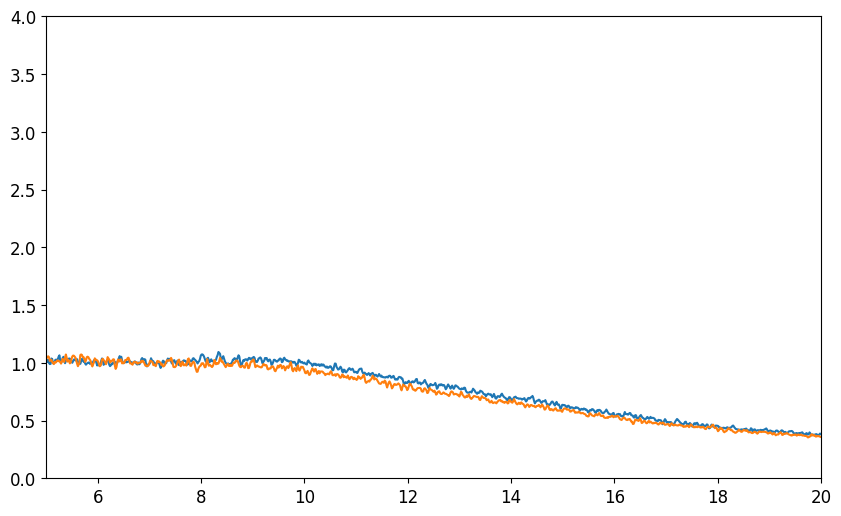

In [135]:
q, I_data_calib = calib(q, I_array)

df = I_array
# plt.plot(q, df[80])
# plt.plot(q, df[90])
plt.plot(q, df[115])
plt.plot(q, df[140])

plt.xlim(5, 20)
plt.ylim(0, 4)

left = 8.2
right = 9

mask = (q > left) * (q < right)
# plt.semilogy()

In [132]:

integral = []

for i in range(200):
    x = q[mask]
    y = I_data_calib[i][mask]
    integral.append(np.trapezoid(y * x ** 2, x  ))

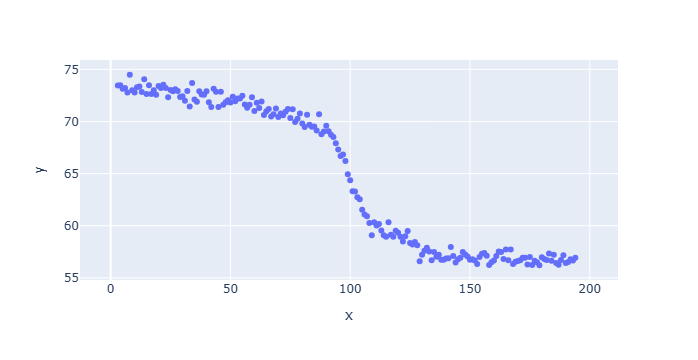

In [133]:
px.scatter(x = range(200), y = integral)